In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv("Heart Attack Data Set.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.duplicated().sum()
df = df.drop_duplicates()

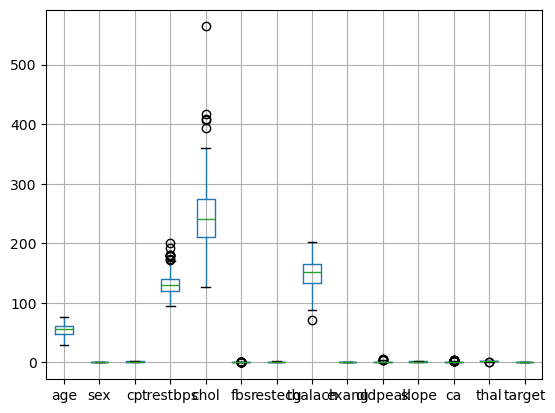

In [5]:
df.boxplot()
plt.show()

In [6]:
#Filtering
df.describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,35.00000,0.000000,0.000000,100.000000,149.000000,0.000000,0.000000,95.010000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
5%,40.00000,0.000000,0.000000,108.000000,175.050000,0.000000,0.000000,108.050000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
95%,68.00000,1.000000,3.000000,160.000000,326.950000,1.000000,1.000000,181.950000,1.000000,3.400000,2.000000,3.000000,3.000000,1.000000
99%,71.00000,1.000000,3.000000,180.000000,406.870000,1.000000,1.990000,191.980000,1.000000,4.200000,2.000000,3.990000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
bounds = {
    'age': (1, 100),
    'sex': (0, 1), 
    'cp': (0, 3), 
    'trestbps': (80, df['trestbps'].quantile(0.99)),
    'chol': (100, df['chol'].quantile(0.99)),
    'fbs': (0, 1),
    'restecg': (0, 2),
    'thalach': (60, df['thalach'].quantile(0.99)),
    'exang': (0, 1),
    'oldpeak': (0, df['oldpeak'].quantile(0.99)),
    'slope': (0, 2),
    'ca': (0, 4),
    'thal': (0, 3),
    'target': (0, 1)
}

for col, (low, high) in bounds.items():
    if col in df.columns:
        df.loc[df[col] < low, col] = low
        df.loc[df[col] > high, col] = high

C:\Users\Hylmi Razzan\AppData\Local\Temp\ipykernel_32104\300431263.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '406.8700000000001' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] > high, col] = high
C:\Users\Hylmi Razzan\AppData\Local\Temp\ipykernel_32104\300431263.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '191.98000000000002' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[col] > high, col] = high


## Split

In [8]:
x = df.drop(["target"], axis = 1)
y = df["target"]

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [10]:
print("x_train size: ", x_train.shape[0])
print("x_test size: ", x_test.shape[0])
print("y_train size: ", y_train.shape[0])
print("y_test size: ", y_test.shape[0])

x_train size:  241
x_test size:  61
y_train size:  241
y_test size:  61


### Base

In [11]:
from sklearn.ensemble import GradientBoostingClassifier
GBM = GradientBoostingClassifier(random_state=42)
GBM.fit(x_train, y_train)

GradientBoostingClassifier(random_state=42)

In [12]:
y_predict1=GBM.predict(x_test)

In [13]:
from sklearn.metrics import classification_report
print('\nClassification Report\n')
print(classification_report(y_test, y_predict1))


Classification Report

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.90      0.81      0.85        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.86      0.85      0.85        61



### Tuning

In [14]:
from sklearn.model_selection import GridSearchCV
param_gb = {

    'learning_rate': [0.01],
    
    'n_estimators': [100],
    
    'max_depth': [3],
    
    'subsample': [0.7],
    
    'max_features': ['sqrt']
}

grid_gb = GridSearchCV(
    estimator=GBM, 
    param_grid=param_gb,
    cv=5, 
    scoring='recall',
    n_jobs=-1
)
grid_gb.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01], 'max_depth': [3],
                         'max_features': ['sqrt'], 'n_estimators': [100],
                         'subsample': [0.7]},
             scoring='recall')

In [15]:
grid_gb.best_params_

{'learning_rate': 0.01,
 'max_depth': 3,
 'max_features': 'sqrt',
 'n_estimators': 100,
 'subsample': 0.7}

In [16]:
gb_tuned_model = grid_gb.best_estimator_

y_pred_tuned = gb_tuned_model.predict(x_test)

In [17]:
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        29
           1       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [18]:
joblib.dump(grid_gb, 'model.pkl')

['model.pkl']

In [20]:
df["cp"].min()

0